In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

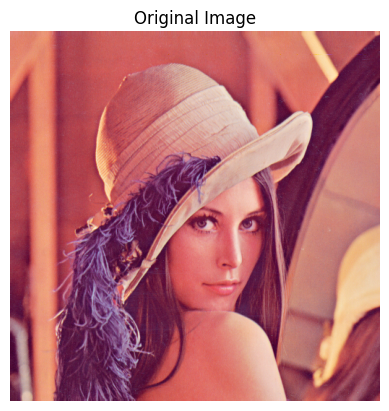

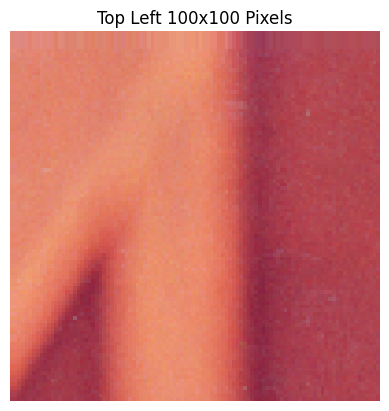

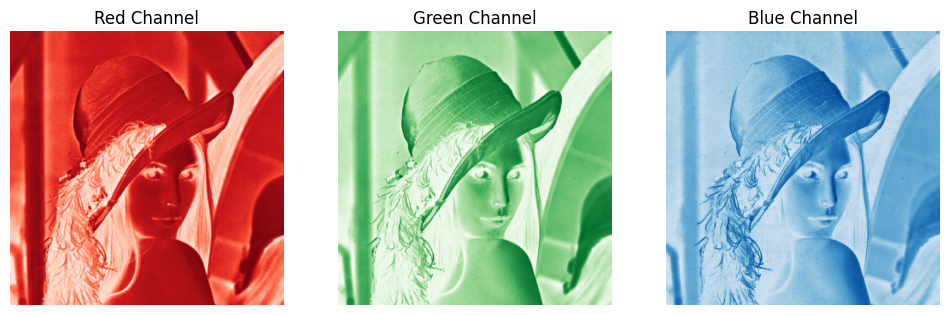

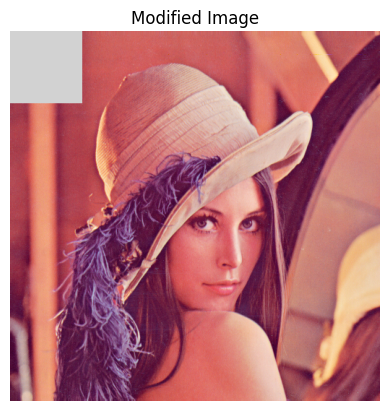

In [4]:
#2.1 Exercise - 1:
#1-Read and Display the Image
img = Image.open("Lenna_(test_image).png")
img_array = np.array(img)

plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()



#2-Display Top Left 100×100 Pixels
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()


#3-Show RGB Channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()



#4-Modify Top 100×100 Pixels to 210
modified = img_array.copy()

modified[0:100, 0:100] = 210

plt.imshow(modified)
plt.title("Modified Image")
plt.axis("off")
plt.show()

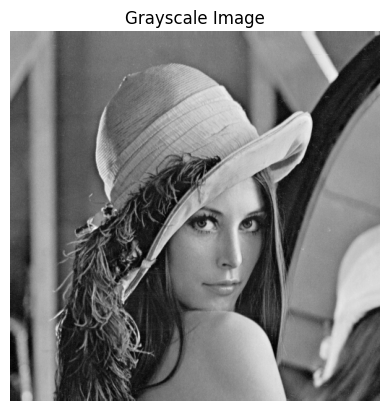

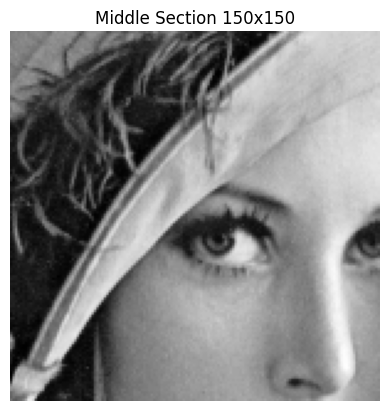

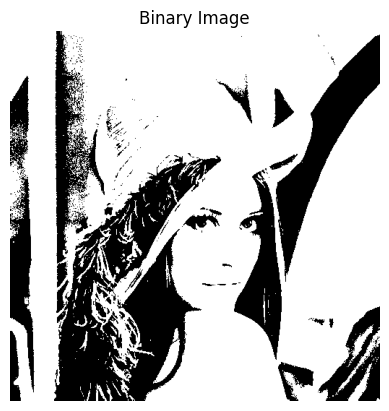

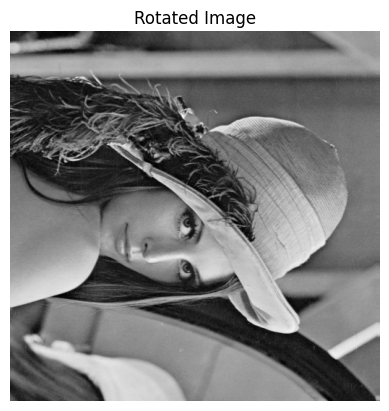

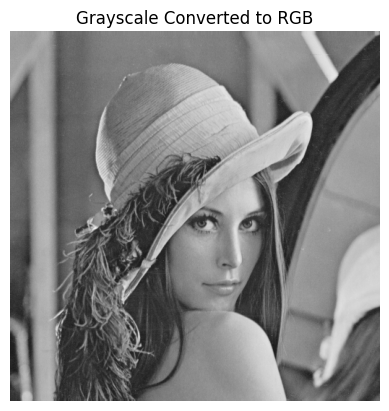

In [5]:
#2.2 Exercise - 2
#1-Convert Image to Grayscale
gray = Image.open("Lenna_(test_image).png").convert("L")
gray_array = np.array(gray)

plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()



#2- Extract Middle 150×150 Section
h, w = gray_array.shape

middle = gray_array[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(middle, cmap="gray")
plt.title("Middle Section 150x150")
plt.axis("off")
plt.show()


#3-Apply a simple threshold to the image
threshold = gray_array.copy()

threshold[threshold < 100] = 0
threshold[threshold >= 100] = 255

plt.imshow(threshold, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()



#4-Rotate the image 90 degrees clockwise
rotated = gray.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image")
plt.axis("off")
plt.show()



#5-Convert the grayscale image to an RGB image.
rgb = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

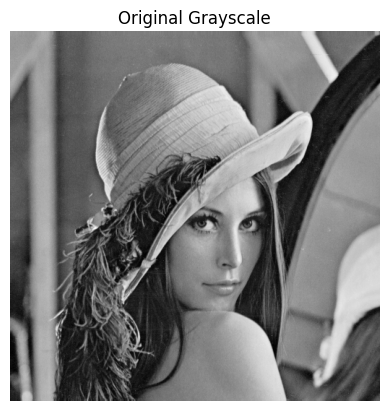

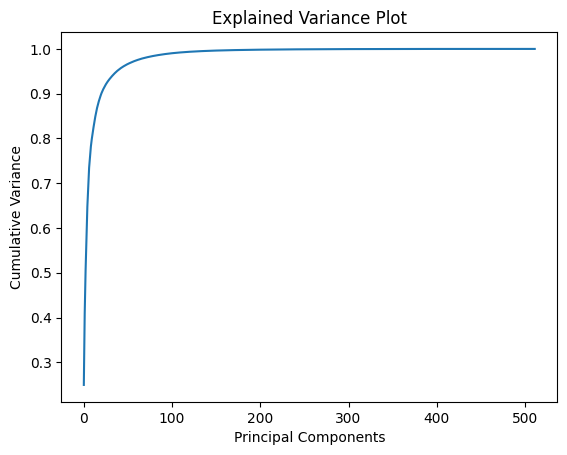

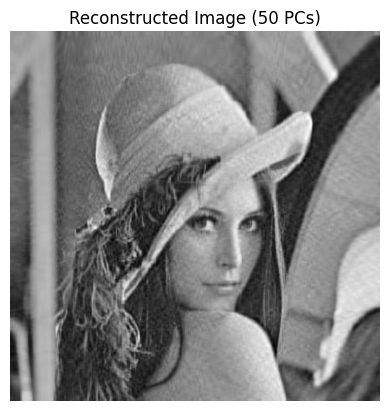

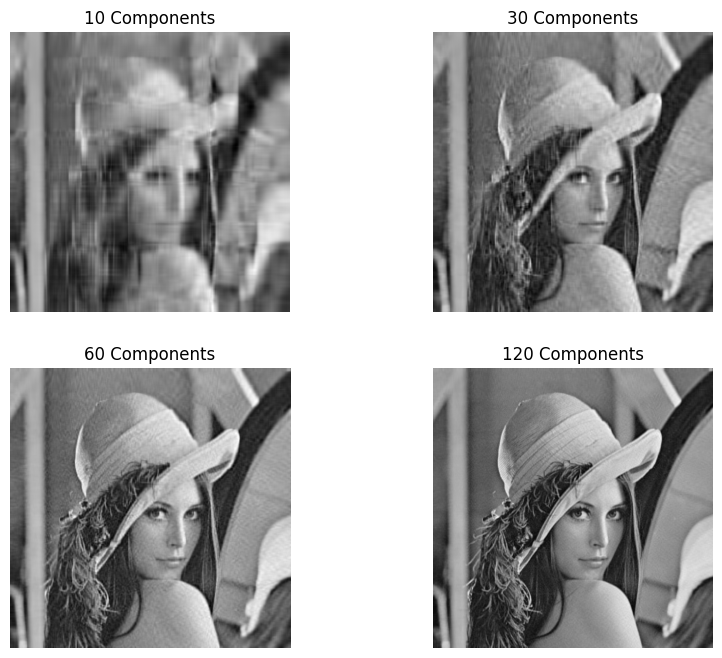

In [7]:
#3 Image Compression and Decompression using PCA.
#1-Load Grayscale Image
img = Image.open("Lenna_(test_image).png").convert("L")
data = np.array(img)

plt.imshow(data, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")
plt.show()


#2-Center the Data
mean = np.mean(data, axis=0)
centered = data - mean


#3-Covariance Matrix
cov_matrix = np.cov(centered, rowvar=False)


#4-Eigenvalues & Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)


#5-Sort Eigenvalues
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]


#6-Explained Variance Plot
explained = eigenvalues / np.sum(eigenvalues)
cumulative = np.cumsum(explained)

plt.plot(cumulative)
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance")
plt.title("Explained Variance Plot")
plt.show()


#7-PCA Reconstruction
k = 50
pcs = eigenvectors[:, :k]
compressed = np.dot(centered, pcs)
reconstructed = np.dot(compressed, pcs.T) + mean



#8-Show Reconstructed Image
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed Image (50 PCs)")
plt.axis("off")
plt.show()



#9-Experiment with Different Components
components = [10, 30, 60, 120]
plt.figure(figsize=(10,8))

for i,k in enumerate(components):

    pcs = eigenvectors[:, :k]
    compressed = np.dot(centered, pcs)
    reconstructed = np.dot(compressed, pcs.T) + mean

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"{k} Components")
    plt.axis("off")

plt.show()
